# Лабораторная работа 6
## Понижение размерности. Отбор признаков. Извлечение признаков

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, r2_score, mean_absolute_error

# Отбор признаков
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression, RFE

# Извлечение признаков
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
import umap

# Модели
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

## 2. Загрузка данных

In [2]:
# Классификация — студенты
df_cls = pd.read_csv('../lab3/stud_end.csv', index_col=0)
X_cls = df_cls.drop(columns=['Target'])
y_cls = df_cls['Target']

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_cls_train_sc = scaler_cls.fit_transform(X_cls_train)
X_cls_test_sc  = scaler_cls.transform(X_cls_test)

print(f"Классификация: train {X_cls_train_sc.shape}, test {X_cls_test_sc.shape}")
print(f"Классы: {y_cls.value_counts().to_dict()}")

Классификация: train (2536, 95), test (635, 95)
Классы: {2: 1946, 1: 654, 0: 571}


In [3]:
# Регрессия — автомобили
df_reg = pd.read_csv('../lab4/cars_end.csv', index_col=0)
X_reg = df_reg.drop(columns=['price_usd'])
y_reg = df_reg['price_usd']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print(f"Регрессия: train {X_reg_train_sc.shape}, test {X_reg_test_sc.shape}")

Регрессия: train (30792, 46), test (7699, 46)


## 3. Понижение размерности
### 3.1 Методы отбора и извлечения признаков

#### VarianceThreshold
Удаляет признаки с дисперсией ниже порога — не нуждается в метке класса.

In [4]:
vt_cls = VarianceThreshold(threshold=0.01)
X_cls_vt       = vt_cls.fit_transform(X_cls_train_sc)
X_cls_vt_test  = vt_cls.transform(X_cls_test_sc)
cls_cols_vt = X_cls.columns[vt_cls.get_support()]
print(f"[Классификация] VarianceThreshold: {X_cls_train_sc.shape[1]} → {X_cls_vt.shape[1]} признаков")
print(f"Оставлены: {list(cls_cols_vt[:10])} ...")

vt_reg = VarianceThreshold(threshold=0.01)
X_reg_vt       = vt_reg.fit_transform(X_reg_train_sc)
X_reg_vt_test  = vt_reg.transform(X_reg_test_sc)
reg_cols_vt = X_reg.columns[vt_reg.get_support()]
print(f"\n[Регрессия]     VarianceThreshold: {X_reg_train_sc.shape[1]} → {X_reg_vt.shape[1]} признаков")

[Классификация] VarianceThreshold: 95 → 95 признаков
Оставлены: ['Daytime/evening attendance\t', 'Previous qualification (grade)', 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment'] ...

[Регрессия]     VarianceThreshold: 46 → 46 признаков


#### SelectKBest
Отбирает K признаков по статистическому критерию: `f_classif` (ANOVA F) для классификации, `f_regression` для регрессии.

In [5]:
K = 20

skb_cls = SelectKBest(f_classif, k=K).fit(X_cls_train_sc, y_cls_train)
X_cls_skb = skb_cls.transform(X_cls_train_sc)
cls_cols_skb = X_cls.columns[skb_cls.get_support()]
print(f"[Классификация] SelectKBest(k={K}): {X_cls_train_sc.shape[1]} → {X_cls_skb.shape[1]}")
print(f"Топ признаки: {list(cls_cols_skb)}\n")

skb_reg = SelectKBest(f_regression, k=K).fit(X_reg_train_sc, y_reg_train)
X_reg_skb = skb_reg.transform(X_reg_train_sc)
reg_cols_skb = X_reg.columns[skb_reg.get_support()]
print(f"[Регрессия]     SelectKBest(k={K}): {X_reg_train_sc.shape[1]} → {X_reg_skb.shape[1]}")
print(f"Топ признаки: {list(reg_cols_skb)}")

[Классификация] SelectKBest(k=20): 95 → 20
Топ признаки: ['Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Application mode_39', 'Course_9119', 'Course_9147', 'Course_9238', 'Course_9500', 'Course_9853', 'Course_9991']

[Регрессия]     SelectKBest(k=20): 46 → 20
Топ признаки: ['transmission', 'odometer_value', 'year_produced', 'engine_capacity', 'has_warranty', 'state', 'drivetrain', 'number_of_photos', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'loc_Минская обл.', 'body_suv']


#### RFE (Recursive Feature Elimination)
Рекурсивно обучает модель и убирает наименее важные признаки. Используется сэмпл данных для ускорения.

In [6]:
from sklearn.svm import SVR, LinearSVC

N_SAMPLE = 3000
n_cls = min(N_SAMPLE, len(X_cls_train_sc))
n_reg = min(N_SAMPLE, len(X_reg_train_sc))
idx_cls = np.random.RandomState(42).choice(len(X_cls_train_sc), n_cls, replace=False)
idx_reg = np.random.RandomState(42).choice(len(X_reg_train_sc), n_reg, replace=False)

rfe_cls = RFE(LogisticRegression(max_iter=300, random_state=42), n_features_to_select=20, step=5)
rfe_cls.fit(X_cls_train_sc[idx_cls], y_cls_train.iloc[idx_cls])
cls_cols_rfe = X_cls.columns[rfe_cls.get_support()]
print(f"[Классификация] RFE: {X_cls_train_sc.shape[1]} → 20 признаков (сэмпл {n_cls})")
print(f"Отобраны: {list(cls_cols_rfe)}\n")

rfe_reg = RFE(Ridge(), n_features_to_select=20, step=5)
rfe_reg.fit(X_reg_train_sc[idx_reg], y_reg_train.iloc[idx_reg])
reg_cols_rfe = X_reg.columns[rfe_reg.get_support()]
print(f"[Регрессия]     RFE: {X_reg_train_sc.shape[1]} → 20 признаков (сэмпл {n_reg})")
print(f"Отобраны: {list(reg_cols_rfe)}")

[Классификация] RFE: 95 → 20 признаков (сэмпл 2536)
Отобраны: ['Tuition fees up to date', 'Scholarship holder', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Application mode_53', 'Course_8014', 'Course_9085', 'Course_9147', 'Course_9238', 'Course_9254', 'Course_9500', 'Course_9670', 'Course_9773', 'Previous qualification_3', 'Previous qualification_42', "Mother's qualification_34"]

[Регрессия]     RFE: 46 → 20 признаков (сэмпл 3000)
Отобраны: ['transmission', 'odometer_value', 'year_produced', 'engine_has_gas', 'engine_capacity', 'has_warranty', 'state', 'drivetrain', 'number_of_photos', 'feature_1', 'feature_3', 'feature_6', 'feature_7', 'duration_listed', 'body_cabriolet', 'body_minibus', 'body_suv', 'fuel_diesel', 'fuel_gas', 'fuel_gasoline']


#### PCA (Principal Component Analysis)
Линейное преобразование: новые оси — направления максимальной дисперсии. График объяснённой дисперсии помогает выбрать число компонент.

[Классификация] PCA 10 компонент объясняют 30.7% дисперсии
[Регрессия]     PCA 10 компонент объясняют 48.1% дисперсии


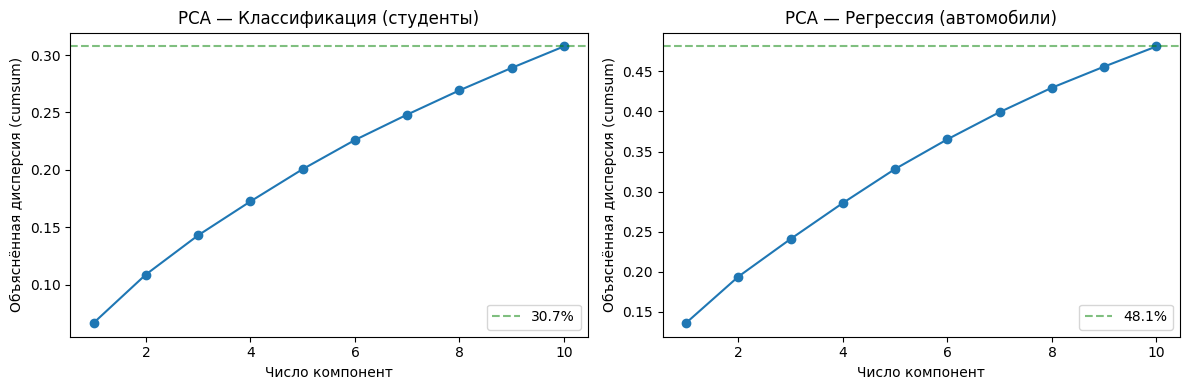

In [7]:
N_COMPONENTS = 10

pca_cls = PCA(n_components=N_COMPONENTS, random_state=42).fit(X_cls_train_sc)
X_cls_pca_train = pca_cls.transform(X_cls_train_sc)
X_cls_pca_test  = pca_cls.transform(X_cls_test_sc)

pca_reg = PCA(n_components=N_COMPONENTS, random_state=42).fit(X_reg_train_sc)
X_reg_pca_train = pca_reg.transform(X_reg_train_sc)
X_reg_pca_test  = pca_reg.transform(X_reg_test_sc)

print(f"[Классификация] PCA {N_COMPONENTS} компонент объясняют {pca_cls.explained_variance_ratio_.sum()*100:.1f}% дисперсии")
print(f"[Регрессия]     PCA {N_COMPONENTS} компонент объясняют {pca_reg.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pca, title in zip(axes,
                           [pca_cls, pca_reg],
                           ['Классификация (студенты)', 'Регрессия (автомобили)']):
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(range(1, N_COMPONENTS + 1), cumvar, marker='o')
    ax.axhline(cumvar[-1], ls='--', color='green', alpha=0.5, label=f'{cumvar[-1]*100:.1f}%')
    ax.set_xlabel('Число компонент')
    ax.set_ylabel('Объяснённая дисперсия (cumsum)')
    ax.set_title(f'PCA — {title}')
    ax.legend()
plt.tight_layout()
plt.show()

#### Kernel PCA
Нелинейный PCA через kernel trick. Проверяем три ядра: `poly`, `rbf`, `sigmoid`.

In [8]:
kernels = ['poly', 'rbf', 'sigmoid']

N_KPCA = 2000
idx_kpca_cls = np.random.RandomState(0).choice(len(X_cls_train_sc), N_KPCA, replace=False)
idx_kpca_reg = np.random.RandomState(0).choice(len(X_reg_train_sc), N_KPCA, replace=False)

print("=== Классификация (студенты) ===")
for kernel in kernels:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_tr = kpca.fit_transform(X_cls_train_sc[idx_kpca_cls])
    print(f"  KernelPCA(kernel={kernel:>8}): {X_cls_train_sc.shape[1]} → {X_tr.shape[1]}")

print("\n=== Регрессия (автомобили) ===")
for kernel in kernels:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_tr = kpca.fit_transform(X_reg_train_sc[idx_kpca_reg])
    print(f"  KernelPCA(kernel={kernel:>8}): {X_reg_train_sc.shape[1]} → {X_tr.shape[1]}")

# Сохраняем rbf для оценки в 3.2 (обучен на сэмпле, transform работает для новых точек)
kpca_cls = KernelPCA(n_components=10, kernel='rbf', random_state=42)
X_cls_kpca_train = kpca_cls.fit_transform(X_cls_train_sc[idx_kpca_cls])
X_cls_kpca_test  = kpca_cls.transform(X_cls_test_sc)

kpca_reg = KernelPCA(n_components=10, kernel='rbf', random_state=42)
X_reg_kpca_train = kpca_reg.fit_transform(X_reg_train_sc[idx_kpca_reg])
X_reg_kpca_test  = kpca_reg.transform(X_reg_test_sc)

=== Классификация (студенты) ===
  KernelPCA(kernel=    poly): 95 → 10
  KernelPCA(kernel=     rbf): 95 → 10
  KernelPCA(kernel= sigmoid): 95 → 10

=== Регрессия (автомобили) ===
  KernelPCA(kernel=    poly): 46 → 10
  KernelPCA(kernel=     rbf): 46 → 10
  KernelPCA(kernel= sigmoid): 46 → 10


#### t-SNE
Нелинейный метод для визуализации. Хорошо сохраняет локальную структуру, но не подходит для обучения моделей — нет `transform` для новых точек.

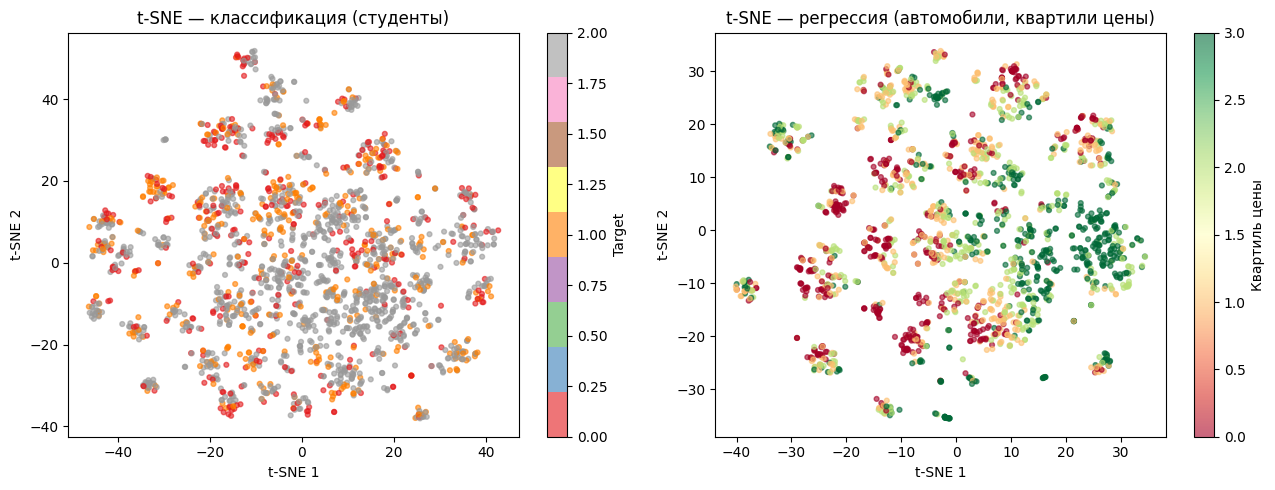

In [9]:
N_TSNE = 2000
idx_t_cls = np.random.RandomState(42).choice(len(X_cls_train_sc), N_TSNE, replace=False)
idx_t_reg = np.random.RandomState(42).choice(len(X_reg_train_sc), N_TSNE, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_cls_tsne = tsne.fit_transform(X_cls_train_sc[idx_t_cls])

tsne_reg = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_reg_tsne = tsne_reg.fit_transform(X_reg_train_sc[idx_t_reg])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(X_cls_tsne[:, 0], X_cls_tsne[:, 1],
                      c=y_cls_train.iloc[idx_t_cls], cmap='Set1', alpha=0.6, s=12)
axes[0].set_title('t-SNE — классификация (студенты)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
plt.colorbar(sc0, ax=axes[0], label='Target')

price_q = pd.qcut(y_reg_train.iloc[idx_t_reg], q=4, labels=False)
sc1 = axes[1].scatter(X_reg_tsne[:, 0], X_reg_tsne[:, 1],
                      c=price_q, cmap='RdYlGn', alpha=0.6, s=12)
axes[1].set_title('t-SNE — регрессия (автомобили, квартили цены)')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc1, ax=axes[1], label='Квартиль цены')

plt.tight_layout(); plt.show()

#### Isomap
Нелинейный метод, основанный на геодезических расстояниях на многообразии. Есть `transform` для новых точек.

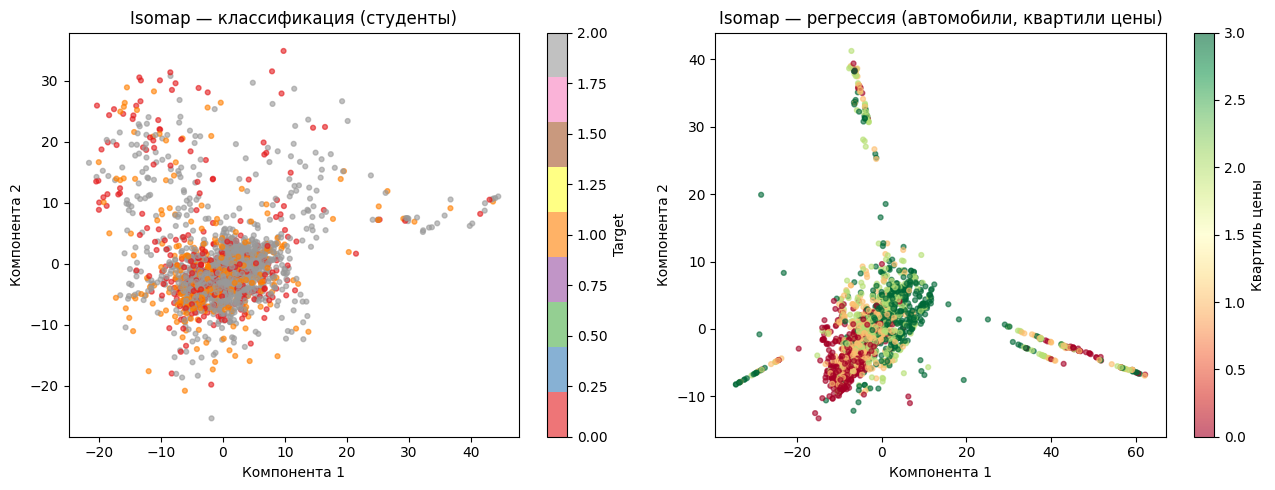

[Классификация] Isomap: 95 → 10
[Регрессия]     Isomap: 46 → 10


In [10]:
N_ISO = 2000
idx_iso_cls = np.random.RandomState(42).choice(len(X_cls_train_sc), N_ISO, replace=False)
idx_iso_reg = np.random.RandomState(42).choice(len(X_reg_train_sc), N_ISO, replace=False)

isomap_cls = Isomap(n_components=10, n_neighbors=10)
X_cls_iso      = isomap_cls.fit_transform(X_cls_train_sc[idx_iso_cls])
X_cls_iso_test = isomap_cls.transform(X_cls_test_sc)

isomap_reg = Isomap(n_components=10, n_neighbors=10)
X_reg_iso      = isomap_reg.fit_transform(X_reg_train_sc[idx_iso_reg])
X_reg_iso_test = isomap_reg.transform(X_reg_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(X_cls_iso[:, 0], X_cls_iso[:, 1],
                      c=y_cls_train.iloc[idx_iso_cls], cmap='Set1', alpha=0.6, s=12)
axes[0].set_title('Isomap — классификация (студенты)')
axes[0].set_xlabel('Компонента 1'); axes[0].set_ylabel('Компонента 2')
plt.colorbar(sc0, ax=axes[0], label='Target')

price_q2 = pd.qcut(y_reg_train.iloc[idx_iso_reg], q=4, labels=False)
sc1 = axes[1].scatter(X_reg_iso[:, 0], X_reg_iso[:, 1],
                      c=price_q2, cmap='RdYlGn', alpha=0.6, s=12)
axes[1].set_title('Isomap — регрессия (автомобили, квартили цены)')
axes[1].set_xlabel('Компонента 1'); axes[1].set_ylabel('Компонента 2')
plt.colorbar(sc1, ax=axes[1], label='Квартиль цены')

plt.tight_layout(); plt.show()
print(f"[Классификация] Isomap: {X_cls_train_sc.shape[1]} → {X_cls_iso.shape[1]}")
print(f"[Регрессия]     Isomap: {X_reg_train_sc.shape[1]} → {X_reg_iso.shape[1]}")

#### UMAP
Быстрее t-SNE, лучше сохраняет глобальную структуру. Поддерживает `transform` для новых точек, пригоден для обучения моделей.

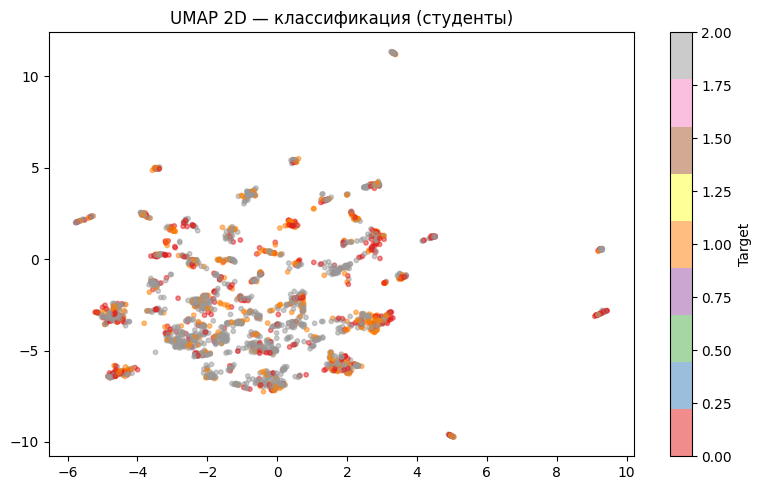

UMAP: 95 → 10 компонент


In [11]:
reducer_cls = umap.UMAP(n_components=10, random_state=42)
X_cls_umap_train = reducer_cls.fit_transform(X_cls_train_sc)
X_cls_umap_test  = reducer_cls.transform(X_cls_test_sc)

reducer_reg = umap.UMAP(n_components=10, random_state=42)
X_reg_umap_train = reducer_reg.fit_transform(X_reg_train_sc)
X_reg_umap_test  = reducer_reg.transform(X_reg_test_sc)

# Визуализация 2D проекции (первые 2 компоненты)
reducer_vis = umap.UMAP(n_components=2, random_state=42)
X_vis = reducer_vis.fit_transform(X_cls_train_sc)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1],
                      c=y_cls_train, cmap='Set1', alpha=0.5, s=10)
plt.colorbar(scatter, label='Target')
plt.title('UMAP 2D — классификация (студенты)')
plt.tight_layout(); plt.show()
print(f"UMAP: {X_cls_train_sc.shape[1]} → {X_cls_umap_train.shape[1]} компонент")

### 3.2 Обучение моделей в пространстве низкой размерности

Выбраны:
- **Классификация** — LogisticRegression (сравнимо с ЛР3)
- **Регрессия** — Ridge (сравнимо с ЛР2)

Для каждого метода понижения размерности (кроме t-SNE — нет `transform` для новых точек) обучаем выбранные модели и сравниваем с baseline. KernelPCA и Isomap обучены на сэмпле 2000 строк.

In [12]:
results = []

def add_result(name, n_cls, X_cls_tr, X_cls_te, n_reg, X_reg_tr, X_reg_te):
    lr = LogisticRegression(max_iter=500, random_state=42).fit(X_cls_tr, y_cls_train)
    f1 = f1_score(y_cls_test, lr.predict(X_cls_te), average='weighted')
    rg = Ridge().fit(X_reg_tr, y_reg_train)
    r2 = r2_score(y_reg_test, rg.predict(X_reg_te))
    results.append({'Метод': name,
                    'Признаков (cls)': n_cls, 'F1 (cls)': round(f1, 4),
                    'Признаков (reg)': n_reg, 'R² (reg)': round(r2, 4)})

# Baseline
add_result('Все признаки (baseline)',
           X_cls_train_sc.shape[1], X_cls_train_sc, X_cls_test_sc,
           X_reg_train_sc.shape[1], X_reg_train_sc, X_reg_test_sc)

# VarianceThreshold
add_result('VarianceThreshold',
           X_cls_vt.shape[1], X_cls_vt, X_cls_vt_test,
           X_reg_vt.shape[1], X_reg_vt, X_reg_vt_test)

# SelectKBest
X_cls_skb_test = skb_cls.transform(X_cls_test_sc)
X_reg_skb_test = skb_reg.transform(X_reg_test_sc)
add_result(f'SelectKBest (k={K})',
           K, X_cls_skb, X_cls_skb_test,
           K, X_reg_skb, X_reg_skb_test)

# RFE
X_cls_rfe_tr = rfe_cls.transform(X_cls_train_sc)
X_cls_rfe_te = rfe_cls.transform(X_cls_test_sc)
X_reg_rfe_tr = rfe_reg.transform(X_reg_train_sc)
X_reg_rfe_te = rfe_reg.transform(X_reg_test_sc)
add_result('RFE (20 признаков)',
           20, X_cls_rfe_tr, X_cls_rfe_te,
           20, X_reg_rfe_tr, X_reg_rfe_te)

# PCA
add_result(f'PCA ({N_COMPONENTS} компонент)',
           N_COMPONENTS, X_cls_pca_train, X_cls_pca_test,
           N_COMPONENTS, X_reg_pca_train, X_reg_pca_test)

# KernelPCA rbf — трансформер обучен на сэмпле, transform применяем к полному train
X_cls_kpca_tr_all = kpca_cls.transform(X_cls_train_sc)
X_reg_kpca_tr_all = kpca_reg.transform(X_reg_train_sc)
add_result('KernelPCA rbf (10 компонент)',
           10, X_cls_kpca_tr_all, X_cls_kpca_test,
           10, X_reg_kpca_tr_all, X_reg_kpca_test)

# Isomap — аналогично: трансформер на сэмпле, transform на полном train
X_cls_iso_tr_all = isomap_cls.transform(X_cls_train_sc)
X_reg_iso_tr_all = isomap_reg.transform(X_reg_train_sc)
add_result('Isomap (10 компонент)',
           10, X_cls_iso_tr_all, X_cls_iso_test,
           10, X_reg_iso_tr_all, X_reg_iso_test)

# UMAP
add_result('UMAP (10 компонент)',
           10, X_cls_umap_train, X_cls_umap_test,
           10, X_reg_umap_train, X_reg_umap_test)

pd.DataFrame(results)

,Метод,Признаков (cls),F1 (cls),Признаков (reg),R² (reg)
0,Все признаки (baseline),95,0.7312,46,0.7242
1,VarianceThreshold,95,0.7312,46,0.7242
2,SelectKBest (k=20),20,0.7177,20,0.7015
3,RFE (20 признаков),20,0.7251,20,0.7168
4,PCA (10 компонент),10,0.6487,10,0.6735
5,KernelPCA rbf (10 компонент),10,0.5455,10,0.4951
6,Isomap (10 компонент),10,0.4767,10,0.3498
7,UMAP (10 компонент),10,0.4970,10,0.0561


### 3.3 Вывод

#### Результаты ЛР6

**Классификация — F1 weighted (Test):**

| Метод | Признаков | F1 |
|---|---|---|
| Все признаки (baseline) | 95 | **0.7312** |
| VarianceThreshold | 95 | 0.7312 |
| RFE (20 признаков) | 20 | 0.7251 |
| SelectKBest (k=20) | 20 | 0.7177 |
| PCA (10 компонент) | 10 | 0.6487 |
| KernelPCA rbf (10 компонент) | 10 | 0.5455 |
| UMAP (10 компонент) | 10 | 0.4970 |
| Isomap (10 компонент) | 10 | 0.4767 |

**Регрессия — R² (Test):**

| Метод | Признаков | R² |
|---|---|---|
| Все признаки (baseline) | 46 | **0.7242** |
| VarianceThreshold | 46 | 0.7242 |
| RFE (20 признаков) | 20 | 0.7168 |
| SelectKBest (k=20) | 20 | 0.7015 |
| PCA (10 компонент) | 10 | 0.6735 |
| KernelPCA rbf (10 компонент) | 10 | 0.4951 |
| Isomap (10 компонент) | 10 | 0.3498 |
| UMAP (10 компонент) | 10 | 0.0561 |

#### Сравнение с предыдущими лабораторными работами

**Классификация — F1 weighted:**

| Лаба | Модель | F1 |
|---|---|---|
| ЛР3 | Logistic Regression | 0.6363 |
| ЛР3 | SVM (Exponential Kernel) | 0.6096 |
| ЛР4 | LightGBM (Optuna) | **0.7535** |
| ЛР4 | GradientBoosting (Optuna) | 0.7295 |
| ЛР6 | Baseline (LogReg, все признаки) | 0.7312 |
| ЛР6 | LogReg + RFE (20 признаков) | 0.7251 |
| ЛР6 | LogReg + SelectKBest (20 признаков) | 0.7177 |

**Регрессия — R²:**

| Лаба | Модель | R² |
|---|---|---|
| ЛР2 | ElasticNet (Optuna) | 0.8107 |
| ЛР2 | Ridge (Optuna) | 0.8032 |
| ЛР4 | XGBoost (Optuna) | **0.9119** |
| ЛР4 | LightGBM (Optuna) | 0.9111 |
| ЛР6 | Baseline (Ridge, все признаки) | 0.7242 |
| ЛР6 | Ridge + RFE (20 признаков) | 0.7168 |
| ЛР6 | Ridge + SelectKBest (20 признаков) | 0.7015 |

#### Выводы

VarianceThreshold не удалил ни одного признака ни в задаче классификации, ни в задаче регрессии — все признаки после стандартизации имеют достаточную дисперсию. Методы отбора признаков (RFE и SelectKBest) показали наилучшие результаты среди всех методов понижения размерности: при сокращении числа признаков в 4–5 раз потеря качества минимальна (F1 −0.006 и −0.014 соответственно), что говорит о наличии информационно избыточных признаков в исходных данных. RFE незначительно превосходит SelectKBest, так как учитывает взаимодействие признаков через модель, а не оценивает их независимо.

Методы извлечения признаков (PCA, KernelPCA, Isomap, UMAP) уступают методам отбора при использовании с линейными моделями. PCA теряет 8–11% качества, нелинейные методы (KernelPCA, Isomap, UMAP) — от 25% до 90%. Особенно критичен UMAP для регрессии (R² = 0.056): UMAP оптимизирует топологическую структуру данных, а не регрессионную зависимость, из-за чего пространство низкой размерности оказывается непригодным для Ridge. Нелинейные методы хорошо подходят для визуализации, но требуют нелинейных моделей (ансамблей, нейросетей) для получения конкурентного качества.

По сравнению с предыдущими лабораторными работами: в задаче классификации логистическая регрессия на всех признаках (ЛР6, F1 = 0.731) превзошла аналогичную модель из ЛР3 (F1 = 0.636), так как в ЛР6 используется более тщательная предобработка; однако ансамблевые методы из ЛР4 по-прежнему лидируют (LightGBM, F1 = 0.754). В задаче регрессии Ridge уступает и моделям ЛР2 с подобранными гиперпараметрами (R² = 0.810), и бустингу из ЛР4 (R² = 0.912).


## 4. Реализация PCA вручную
### 4.1 CustomPCA

In [13]:
class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        X = np.array(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        X_c = X - self.mean_

        cov = np.cov(X_c.T)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # eigh возвращает в возрастающем порядке — разворачиваем
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.components_ = eigenvectors[:, :self.n_components].T
        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_var
        return self

    def transform(self, X):
        X_c = np.array(X, dtype=float) - self.mean_
        return X_c @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

Объяснённая дисперсия: PC1=6.7%, PC2=4.2%
sklearn PCA:           PC1=6.7%, PC2=4.2%


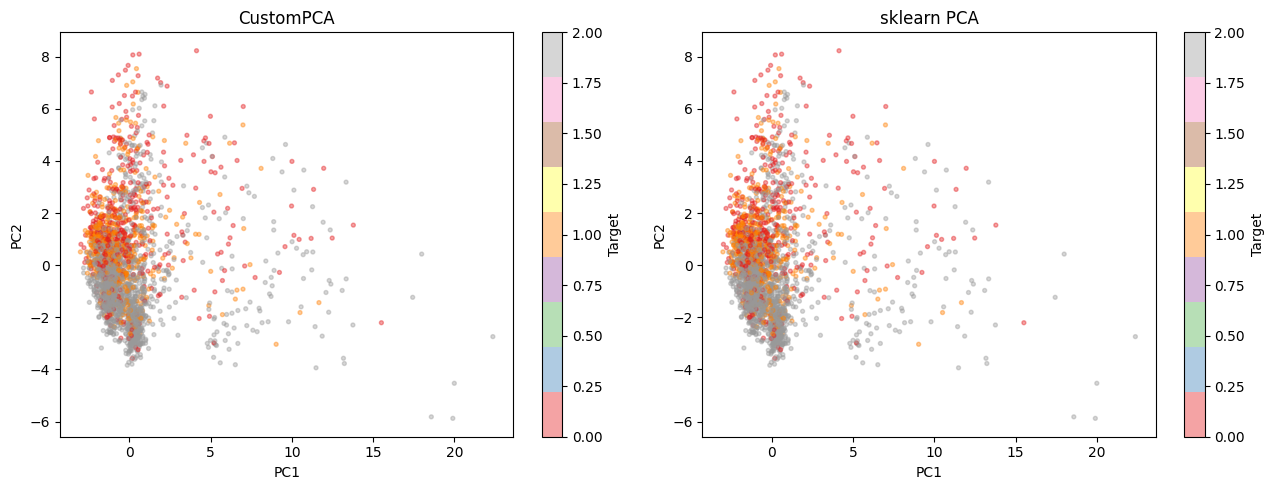

In [14]:
# Понижаем до 2D на данных классификации (без метки)
custom_pca = CustomPCA(n_components=2)
X_cls_2d = custom_pca.fit_transform(X_cls_train_sc)

print(f"Объяснённая дисперсия: PC1={custom_pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={custom_pca.explained_variance_ratio_[1]*100:.1f}%")

# Сравнение с sklearn PCA
pca_sk = PCA(n_components=2, random_state=42).fit(X_cls_train_sc)
print(f"sklearn PCA:           PC1={pca_sk.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca_sk.explained_variance_ratio_[1]*100:.1f}%")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X2d, title in zip(axes,
                            [X_cls_2d, pca_sk.transform(X_cls_train_sc)],
                            ['CustomPCA', 'sklearn PCA']):
    sc = ax.scatter(X2d[:, 0], X2d[:, 1], c=y_cls_train,
                    cmap='Set1', alpha=0.4, s=8)
    ax.set_title(title)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax, label='Target')
plt.tight_layout(); plt.show()

### 4.2 Кластеризация CustomKMeans на PCA-проекции

Используем реализацию k-Means из ЛР5 ([lab5/ml_algorithms.py](../lab5/ml_algorithms.py)).

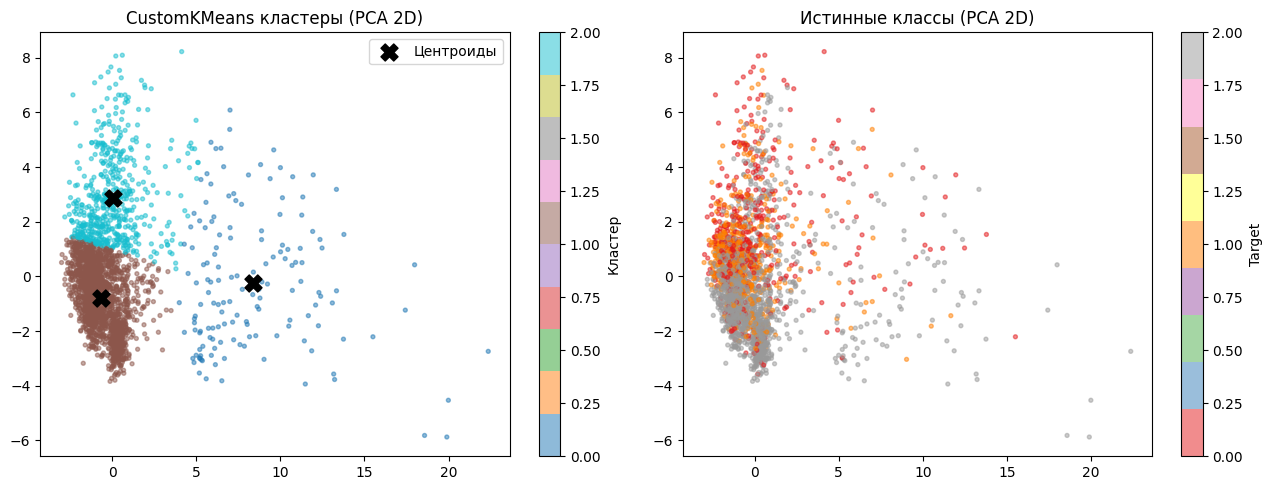

In [15]:
from ml_algorithms import CustomKMeans

# 3 кластера — по числу классов (Dropout, Enrolled, Graduate)
kmeans = CustomKMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_cls_2d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Кластеры CustomKMeans
sc0 = axes[0].scatter(X_cls_2d[:, 0], X_cls_2d[:, 1], c=cluster_labels,
                      cmap='tab10', alpha=0.5, s=8)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='black', marker='X', s=150, zorder=5, label='Центроиды')
axes[0].set_title('CustomKMeans кластеры (PCA 2D)')
axes[0].legend()
plt.colorbar(sc0, ax=axes[0], label='Кластер')

# Истинные метки для сравнения
sc1 = axes[1].scatter(X_cls_2d[:, 0], X_cls_2d[:, 1], c=y_cls_train,
                      cmap='Set1', alpha=0.5, s=8)
axes[1].set_title('Истинные классы (PCA 2D)')
plt.colorbar(sc1, ax=axes[1], label='Target')

plt.tight_layout(); plt.show()

In [16]:
# Интерпретация кластеров: смотрим, какие истинные классы попали в каждый кластер
df_interp = pd.DataFrame({
    'cluster': cluster_labels,
    'true_label': y_cls_train.values
})

label_names = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
df_interp['true_name'] = df_interp['true_label'].map(label_names)

print("Распределение истинных меток по кластерам:")
ct = pd.crosstab(df_interp['cluster'], df_interp['true_name'], normalize='index').round(3)
print(ct)

print("\nПреобладающий класс в каждом кластере:")
for c in sorted(df_interp['cluster'].unique()):
    dominant = df_interp[df_interp['cluster'] == c]['true_name'].value_counts().idxmax()
    size = (df_interp['cluster'] == c).sum()
    print(f"  Кластер {c}: {dominant} (n={size})")

Распределение истинных меток по кластерам:
true_name  Dropout  Enrolled  Graduate
cluster                               
0            0.230     0.108     0.662
1            0.115     0.188     0.696
2            0.391     0.296     0.313

Преобладающий класс в каждом кластере:
  Кластер 0: Graduate (n=148)
  Кластер 1: Graduate (n=1854)
  Кластер 2: Dropout (n=534)
